In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from pathlib import Path
import seaborn as sns 
import matplotlib as mpl
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
import json

In [ ]:
# Functions:

def get_expt_names(metadata: dict):
    """
    Arguments:
        metadata: dictionary containing metadata for all experiments
    Returns:
        list of experiment names (keys of metadata dictionary)"""
    return list(metadata.keys())

def get_plate_d_pix(metadata: dict, expt_names: list)-> dict:
    """
    computes the plate diameter in pixels for each experiment based on the plate diameter in mm and the mm per pixel calibration
    Arguments:
        metadata: dictionary containing metadata for all experiments
        expt_names: list of experiment names (keys of metadata dictionary)
    Returns:
        dictionary with experiment names as keys and plate diameter in pixels as values"""
    plate_d_dict = {}
    for e in expt_names:
        dpix = metadata[e]["acquisition_params"]["plate_diameter_mm"]/metadata[e]["plate_results"]["mm_per_px"]
        plate_d_dict.update({e.replace(".mp4", ""): dpix})
    return plate_d_dict

def get_plate_d_list(expt_names: list, metadata: dict) -> list:
    """ Extracts the plate diameters for chosen experiments from metadata"""
    return [metadata[e]["acquisition_params"]["plate_diameter_mm"] for e in expt_names]

def get_mm_per_pix_list(expt_names: list, metadata: dict) -> list:
    """ Extracts the plate diameters for chosen experiments from metadata"""
    return [metadata[e]["plate_results"]["mm_per_px"] for e in expt_names]

def get_avg_plate_d_pix(plate_d_mm: list, mm_per_pix: list)->int:
    """ Computes average plate diameter, in pixels"""
    return int(round(np.average(plate_d_mm)/np.average(mm_per_pix)))

def compute_tstamp(i: int, n: float, fps: float) -> float:
    """ Computes time stamp (ms) at a given frame index  i based on extraction interval n, and frame rate fps"""
    return ((i*n)/fps)*1000


In [ ]:
# Directory navigation:
parent_folder = Path(r"C:\Users\...\00_processed")  # Enter your folder path here. This folder should contain all the .npz files for analysis.
filelst = list(parent_folder.glob("*.npz"))
filenames = [f.name for f in filelst]

In [ ]:
# Read each file into an array, and store into a dictionary with key  = filename, value = array
# array is of form [frames:contour length: contour y, x1, x2]

data_dict = {}
for i in range(len(filelst)):
    data_dict[filenames[i]] = np.load(filelst[i])["contours"]
data_dict[filenames[0]]


array([[[117. ,  61.5, 249.5],
        [117.5,  62. , 249. ],
        [118. ,  62.5, 248.5],
        ...,
        [  nan,   nan,   nan],
        [  nan,   nan,   nan],
        [  nan,   nan,   nan]],

       [[117. ,  61.5, 249.5],
        [118. ,  62.5, 249.5],
        [118.5,  63. , 249. ],
        ...,
        [  nan,   nan,   nan],
        [  nan,   nan,   nan],
        [  nan,   nan,   nan]],

       [[117. ,  61.5, 249.5],
        [118. ,  62.5, 249.5],
        [119. ,  62.5, 248.5],
        ...,
        [  nan,   nan,   nan],
        [  nan,   nan,   nan],
        [  nan,   nan,   nan]],

       ...,

       [[117. ,  62.5, 250.5],
        [117.5,  63. , 250. ],
        [118. ,  63.5, 249.5],
        ...,
        [  nan,   nan,   nan],
        [  nan,   nan,   nan],
        [  nan,   nan,   nan]],

       [[117. ,  62.5, 250.5],
        [118. ,  62.5, 250.5],
        [118.5,  63. , 250. ],
        ...,
        [  nan,   nan,   nan],
        [  nan,   nan,   nan],
        [  nan,

In [ ]:
# Open metadata file
with open(r"C:\Users\...\00_processed\expt_analysis_metadata.json", "r" ) as file:  # paste your filepath to the metadata json file here
    metadata = json.load(file)

# Get experiments we want to analyze
expt_names = list(metadata.keys())

# get plate diameters -> create a dictionary with key = experiment name (without extension), value = diameter (pixels)
plate_d_dict = get_plate_d_pix(metadata, expt_names)
plate_d_dict

# compute the average mm->px calibration 
mmpx = []
for f in filenames:
    expt_metadata = metadata[f.replace("_contours.npz",".mp4")]
    mm_per_px = expt_metadata["plate_results"]["mm_per_px"]
    mmpx.append(mm_per_px)
avg_mmpx = np.average(mmpx)

In [6]:
# Compute diameters - keep only diameters less thaN plate diameter. 

for f in filenames:
    arr = data_dict[f] # Get array
    plate_d_pix = plate_d_dict[f.replace("_contours.npz", "")] # get diameter of plate

    # compute diameters across every y value in the contour
    d = abs(arr[:,:,1] - arr[:,:,2])

    # Add these diameters to the existing array to expand from [frames, contour lengths, 3] to [frames, contour lengths, 4], where the third dimension now has y, x1, x2, diameter (pixels)
    d = d[:,:, np.newaxis]
    data_dict[f] = np.concatenate((arr, d), axis = 2)

    # Convert all diameters found to be greater than the plate diameter to np.nan to filter out any diameter that didn't correspond to the filament. 
    # (Filament diameter can only ever be smaller than the plate diameter)
    mask = data_dict[f][:, :, 3] > plate_d_pix
    data_dict[f][mask] = np.nan

data_dict[filenames[1]]


array([[[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       ...,

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan

In [7]:
# Generating dataframes of time (ms) vs diameters and dependencies (mm), 
# and storing as dictionary with key = experiment name, value = dataframe (time vs diameters)

df_dict = {}
for f in filenames:
    expt_metadata = metadata[f.replace("_contours.npz",".mp4")]
    n = expt_metadata["acquisition_params"]["extraction_interval"]
    fps = expt_metadata["acquisition_params"]["frame_rate_fps"]
    mm_per_px = expt_metadata["plate_results"]["mm_per_px"]  # Replace avg_mmpx to mm_per_px if you want to use the individual experiment's mm->pixel calibration.
                                                        # Current setup uses the average mm->px calibration across all experiments. (Calculated above)

    df = pd.DataFrame()
    arr = data_dict[f]  # Read in the array of contours for the experiment

    # compute time stamp of each frame in milliseconds
    tstamps = np.array([compute_tstamp(i = i, n = n, fps = fps) for i in range(arr.shape[0])])

    # compute minimum diameter per frame
    # min_d = (np.nanmin(arr[:,:,3], axis = 1))*mm_per_px
    min_d = (np.nanmin(arr[:,:,3], axis = 1))*avg_mmpx

    # create dataframe
    df["t, ms"] = tstamps
    df["minimum_diameter, mm"] = min_d

    df_dict.update({f: df})

df_dict[filenames[10]].head(20)


,"t, ms","minimum_diameter, mm"
0,0.0,3.691732
1,1.0,3.734659
2,2.0,3.691732
3,3.0,3.691732
4,4.0,3.691732
5,5.0,3.691732
6,6.0,3.691732
7,7.0,3.691732
8,8.0,3.691732
9,9.0,3.691732


In [ ]:
# Saving data to CSV
for f in filenames:
    df_dict[f].to_csv(fr"{parent_folder}\{f.replace(".npz", "")}.csv", index = False)

100mM_tru_C001H001S0001_20260324_164830_contours.npz


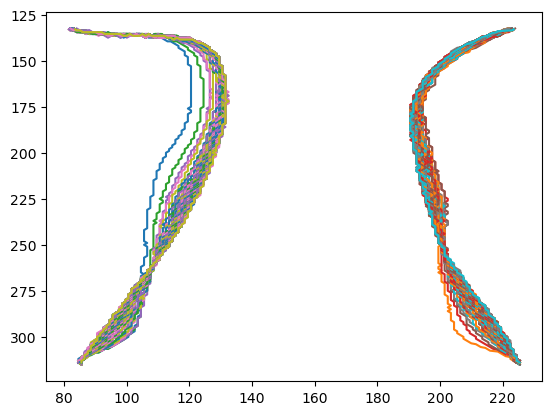

In [ ]:
# Plot contours
plt.figure()
f = filenames[1] # Choose your file
arr = data_dict[f].copy()

for frame in range(0, arr.shape[0], 100):
    y = arr[frame, :, 0]
    x1 = arr[frame, : , 1]
    x2 = arr[frame, : , 2]
    plt.plot(x1, y)
    plt.plot(x2, y)
plt.gca().invert_yaxis() 
print(f)